In [146]:
from pathlib import Path
import os
import sys
import csv

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import cvxpy as cp

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [147]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge / (4 * mass * Omega**2)

In [148]:
from post_process import read_post_processed
from field_analysis import analyze_dc_pot

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
excitation_electrodes = [3,4,5,6,7, 12,15, 16,17,18,19,21]
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_list=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: [3, 4, 5, 6, 7, 12, 15, 16, 17, 18, 19, 21]


In [149]:
dc_fields = {}

x0 = -250e-6
y0 = 0
z0 = 49.99e-6

dr = 2e-6

for i in excitation_electrodes:
    
    coeff, phi, grad, hessian = analyze_dc_pot(x, y, z, potentials[i], x0, y0, z0, dr)

    dc_fields[i] = (coeff, phi, grad, hessian)

## Axial set

In [150]:
from field_analysis import fit_prep, print_field, quadratic_sol

omega = 2 * np.pi * 1e6
V_max = 5
c_Vk = 1e-4

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = np.array([-0.2]), target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))

x = cp.Variable(len(excitation_electrodes))

objective = cp.Minimize(cp.sum_squares(A @ x - b)+ c_Vk * cp.sum_squares(x))
constraints = [cp.abs(x) <= V_max]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

V_axial = x.value

out_csv = Path("control_voltage/axial_set.csv")  # saved in current working directory
with out_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["electrode", "voltage_V"])
    for electrode, voltage in zip(excitation_electrodes, V_axial):
        writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/axial_set.csv


Phi: -0.19402633223926713
Grad: [ 2.72261732e-07  3.45607987e-10 -7.41053432e-07]
Hessian: [[ 1.63665986e+07 -2.18278728e-10 -1.00094439e-08]
 [-2.18278728e-10 -8.18329931e+06  2.98023224e-08]
 [-1.00094439e-08  2.98023224e-08 -8.18329931e+06]]
Delta Pos (um): [-1.66352055e-08  4.22333308e-11 -9.05568041e-08]


(-0.3, 0.0)

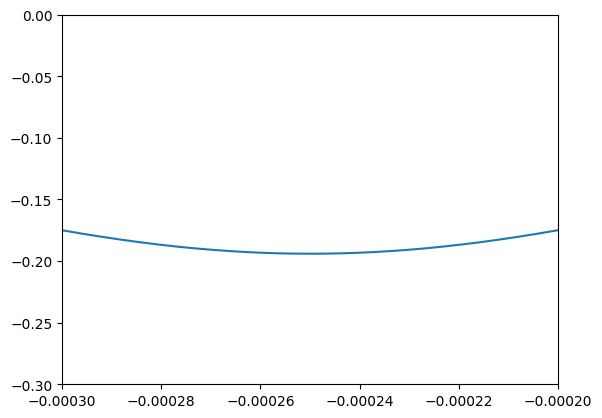

In [151]:
print_field(A @ x.value, delta_pos=True)

potential_space = np.zeros_like(y)
coeff = x.value
for i in range(len(coeff)):

    electrode_i = excitation_electrodes[i]
    potential_space = potential_space + coeff[i] *  potentials[electrode_i]

y0_index = np.argmin(np.abs(y_axis - y0))
z0_index = np.argmin(np.abs(z_axis - z0))
target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge)
plt.plot(x_axis, potential_space[:, y0_index, z0_index])
plt.plot(x_axis,1/2*target_hessian[0,0]*(x_axis+250e-6)**2)
plt.xlim(-300e-6, -200e-6)
plt.ylim(-0.3, 0)

## Compensation set

In [152]:
omega = 2 * np.pi * 1e6
V_max = 5
c_Vk = 1e-3
omega_r = 2 * np.pi * 4e6
target_grad = np.array([-mass*omega**2/(charge) * 1e-6, 0, 0])
target_phi = np.array([0])
target_hessian = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

x = cp.Variable(len(excitation_electrodes))

objective = cp.Minimize(cp.sum_squares(A @ x - b)+ c_Vk * cp.sum_squares(x))
constraints = [cp.abs(x) <= V_max]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

V_xcomp = x.value

out_csv = Path("control_voltage/xcomp_set.csv")  # saved in current working directory
with out_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["electrode", "voltage_V"])
    for electrode, voltage in zip(excitation_electrodes, V_xcomp):
        writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/xcomp_set.csv


In [153]:
print_field(A @ (V_axial + V_xcomp), delta_pos=True)

Phi: -0.1940106732042677
Grad: [-1.63665842e+01 -1.90152605e-09 -7.45331103e-07]
Hessian: [[ 1.63665986e+07  1.16415322e-10 -1.09328084e-07]
 [ 1.16415322e-10 -8.18329931e+06  3.35276127e-08]
 [-1.09328084e-07  3.35276127e-08 -8.18329931e+06]]
Delta Pos (um): [ 9.99999118e-01 -2.32366660e-10 -9.10795492e-08]


In [154]:
omega = 2 * np.pi * 1e6
V_max = 5
c_Vk = 1e-3
omega_r = 2 * np.pi * 4e6
target_grad = np.array([0, -mass*omega_r**2/(charge) * 1e-6, 0])
target_phi = np.array([0])
target_hessian = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

x = cp.Variable(len(excitation_electrodes))

objective = cp.Minimize(cp.sum_squares(A @ x - b)+ c_Vk * cp.sum_squares(x))
constraints = [cp.abs(x) <= V_max]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

V_ycomp = x.value

out_csv = Path("control_voltage/ycomp_set.csv")  # saved in current working directory
with out_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["electrode", "voltage_V"])
    for electrode, voltage in zip(excitation_electrodes, V_ycomp):
        writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/ycomp_set.csv


In [155]:
omega = 2 * np.pi * 1e6
V_max = 5
c_Vk = 1e-3
omega_r = 2 * np.pi * 4e6
target_grad = np.array([0, 0, -mass*omega_r**2/(charge) * 1e-6])
target_phi = np.array([0])
target_hessian = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

x = cp.Variable(len(excitation_electrodes))

objective = cp.Minimize(cp.sum_squares(A @ x - b)+ c_Vk * cp.sum_squares(x))
constraints = [cp.abs(x) <= V_max]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

V_zcomp = x.value

out_csv = Path("control_voltage/zcomp_set.csv")  # saved in current working directory
with out_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["electrode", "voltage_V"])
    for electrode, voltage in zip(excitation_electrodes, V_zcomp):
        writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/zcomp_set.csv


## Tilt set

In [156]:
np.linalg.eig([[4,0.5],[0.5,4]])

EigResult(eigenvalues=array([4.5, 3.5]), eigenvectors=array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]]))

In [157]:
omega = 2 * np.pi * 1e6
V_max = 5
c_Vk = 1e-3
omega_r = 2 * np.pi * 4e6
delta_omega = 0.5 * 2 * np.pi * 1e6
target_phi = np.array([0])
target_grad = np.array([0, 0, 0])
target_hessian = np.array([[0, 0, 0], [0, 0, mass*2*delta_omega*omega_r/(charge)], [0, mass*2*delta_omega*omega_r/(charge), 0]])

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = target_phi, target_grad = target_grad, target_hessian = target_hessian)

x = cp.Variable(len(excitation_electrodes))

objective = cp.Minimize(cp.sum_squares(A @ x - b)+ c_Vk * cp.sum_squares(x))
constraints = [cp.abs(x) <= V_max]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

V_tilt = x.value

out_csv = Path("control_voltage/tilt_set.csv")  # saved in current working directory
with out_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["electrode", "voltage_V"])
    for electrode, voltage in zip(excitation_electrodes, V_tilt):
        writer.writerow([electrode, float(voltage)])

print(f"Saved: {out_csv.resolve()}")

Saved: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc/control_voltage/tilt_set.csv


In [158]:
from field_analysis import upper_vector_to_hessian

V_sum = V_axial + V_xcomp + V_ycomp + V_zcomp + V_tilt
b = A @ V_sum

phi, grad, upper_hessian = b[0], b[1:4], b[4:]
hessian = upper_vector_to_hessian(upper_hessian)

In [159]:
hessian = hessian + np.array([[0, 0, 0], [0, 1, 0], [0, 0, 1]]) * mass*(omega_r)**2/(charge)

In [160]:
print(hessian)

[[ 1.63665986e+07 -2.32830644e-10 -1.06071639e-07]
 [-2.32830644e-10  2.53682279e+08  6.54663945e+07]
 [-1.06071639e-07  6.54663945e+07  2.53682279e+08]]


In [161]:
print(f"Phi: {phi}")
print(f"Grad: {grad}")
print(f"Hessian: {hessian}")
print(f"Delta Pos (um): {-jnp.linalg.solve(hessian, grad)*1e6}")

Phi: -0.22209035488782466
Grad: [ -16.36658509 -261.86557856 -261.86557457]
Hessian: [[ 1.63665986e+07 -2.32830644e-10 -1.06071639e-07]
 [-2.32830644e-10  2.53682279e+08  6.54663945e+07]
 [-1.06071639e-07  6.54663945e+07  2.53682279e+08]]
Delta Pos (um): [0.99999917 0.82051283 0.82051281]


In [162]:
eigvals, eigvecs = np.linalg.eigh(hessian)
eigvals = eigvals * charge / mass
print("Secular frequencies (MHz):", np.sqrt(eigvals)/(2*np.pi*1e6))
print("Eigenvectors (principal axes):", eigvecs)

Secular frequencies (MHz): [1.         3.39116499 4.41588043]
Eigenvectors (principal axes): [[ 1.00000000e+00 -4.35494035e-16  2.48259780e-16]
 [-1.32394612e-16 -7.07106781e-01 -7.07106781e-01]
 [ 4.83486959e-16  7.07106781e-01 -7.07106781e-01]]
